# fixed- point Iteration Method.


Iteration	Approximation		Error
1		0.877583		3.775826e-01
2		0.639012		2.385701e-01
3		0.802685		1.636726e-01
4		0.694778		1.079071e-01
5		0.768196		7.341780e-02
6		0.719165		4.903039e-02
7		0.752356		3.319031e-02
8		0.730081		2.227470e-02
9		0.745120		1.503928e-02
10		0.735006		1.011403e-02
11		0.741827		6.820214e-03
12		0.737236		4.590797e-03
13		0.740330		3.093926e-03
14		0.738246		2.083414e-03
15		0.739650		1.403724e-03
16		0.738705		9.454234e-04
17		0.739341		6.369129e-04
18		0.738912		4.290029e-04
19		0.739201		2.889948e-04
20		0.739007		1.946644e-04
21		0.739138		1.311310e-04
22		0.739050		8.833017e-05
23		0.739109		5.950083e-05
24		0.739069		4.008022e-05
25		0.739096		2.699863e-05
26		0.739078		1.818655e-05
27		0.739090		1.225070e-05
28		0.739082		8.252210e-06
29		0.739087		5.558793e-06
30		0.739084		3.744468e-06
31		0.739086		2.522319e-06
32		0.739084		1.699064e-06
33		0.739086		1.144510e-06
34		0.739085		7.709558e-07
35		0.739085		5.193252e-07
36		0.739085		3.498237e-07

Root 

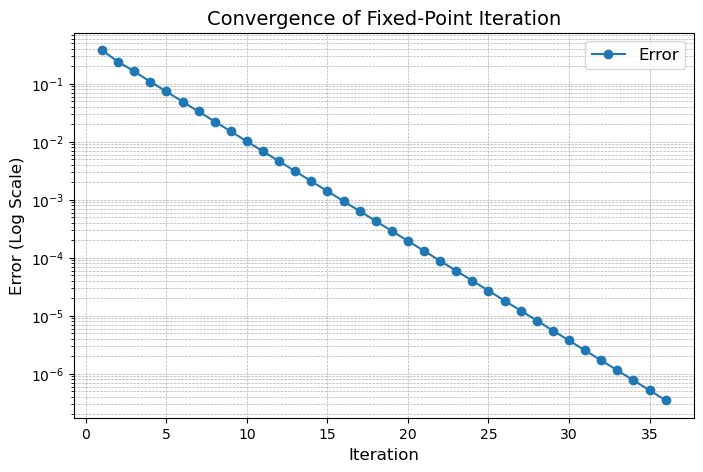

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def fixed_point_iteration(g, x0, tol=0.5e-6, max_iter=100):
    """
    Parameters:
        g (function): Function representing the iteration g(x)
        x0 (float): Initial guess
        tol (float): Tolerance for stopping criterion
        max_iter (int): Maximum number of iterations

    Returns:
        root (float): Approximated root
        error_table (list): (iteration, approximation, error)
    """
    x = x0
    error_table = []

    for i in range(max_iter):
        x_next = g(x)
        error = abs(x_next - x)
        error_table.append((i + 1, x_next, error))

        if error < tol:
            return x_next, error_table

        x = x_next

    raise RuntimeError("Maximum iterations exceeded without convergence.")


# Define g(x)  (x = cos(x))
def g_example(x):
    return np.cos(x)


# Initial guess
x0_example = 0.5   # root lies in [0, 1]

# Solve using fixed-point iteration
root, error_table = fixed_point_iteration(g_example, x0_example)

# Print results
print("Iteration\tApproximation\t\tError")
for row in error_table:
    print(f"{row[0]}\t\t{row[1]:.6f}\t\t{row[2]:.6e}")

print(f"\nRoot ≈ {root:.6f}")

# Plot convergence
iterations = [row[0] for row in error_table]
errors = [row[2] for row in error_table]

plt.figure(figsize=(8, 5))
plt.semilogy(iterations, errors, marker='o', linestyle='-')
plt.title("Convergence of Fixed-Point Iteration", fontsize=14)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Error (Log Scale)", fontsize=12)
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.legend(["Error"], fontsize=12)
plt.show()


# Bisection Method

Root ≈ 1.5213804244995117

Error Table:
           a         b         c      f(c)         Error
0   1.000000  2.000000  1.500000 -0.125000  5.000000e-01
1   1.500000  2.000000  1.750000  1.609375  2.500000e-01
2   1.500000  1.750000  1.625000  0.666016  1.250000e-01
3   1.500000  1.625000  1.562500  0.252197  6.250000e-02
4   1.500000  1.562500  1.531250  0.059113  3.125000e-02
5   1.500000  1.531250  1.515625 -0.034054  1.562500e-02
6   1.515625  1.531250  1.523438  0.012250  7.812500e-03
7   1.515625  1.523438  1.519531 -0.010971  3.906250e-03
8   1.519531  1.523438  1.521484  0.000622  1.953125e-03
9   1.519531  1.521484  1.520508 -0.005179  9.765625e-04
10  1.520508  1.521484  1.520996 -0.002279  4.882812e-04
11  1.520996  1.521484  1.521240 -0.000829  2.441406e-04
12  1.521240  1.521484  1.521362 -0.000103  1.220703e-04
13  1.521362  1.521484  1.521423  0.000259  6.103516e-05
14  1.521362  1.521423  1.521393  0.000078  3.051758e-05
15  1.521362  1.521393  1.521378 -0.000013  1.52

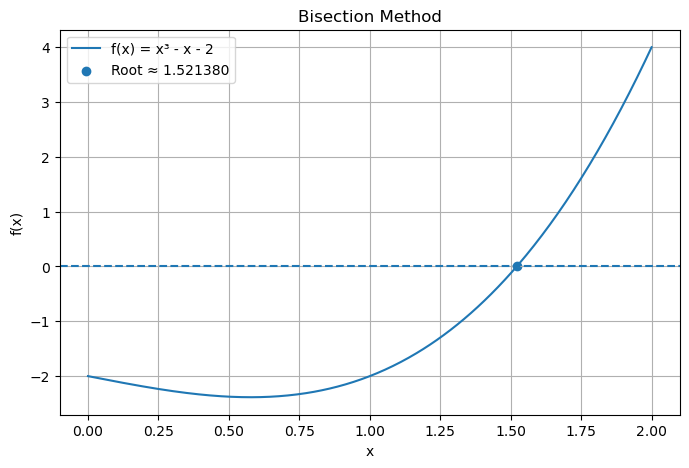

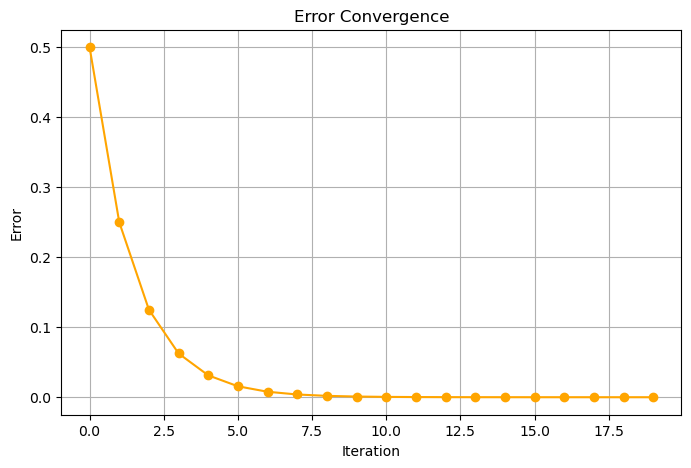

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------
# Bisection Method Function
# -------------------------------
def bisection_method(func, a, b, tol=1e-6, max_iter=100):
    
    if func(a) * func(b) >= 0:
        raise ValueError("f(a) and f(b) must have opposite signs.")

    errors = []
    iterations = []

    for _ in range(max_iter):
        c = (a + b) / 2
        fc = func(c)

        error = abs(b - a) / 2
        errors.append(error)
        iterations.append([a, b, c, fc, error])

        if abs(fc) < tol or error < tol:
            break

        if func(a) * fc < 0:
            b = c
        else:
            a = c

    root = (a + b) / 2
    return root, errors, iterations


# -------------------------------
# Example Function
# -------------------------------
f = lambda x: x**3 - x - 2

# -------------------------------
# Run Bisection
# -------------------------------
root, errors, iterations = bisection_method(f, 1, 2)

print(f"Root ≈ {root}")

# -------------------------------
# Error Table
# -------------------------------
error_table = pd.DataFrame(
    iterations,
    columns=["a", "b", "c", "f(c)", "Error"]
)

print("\nError Table:")
print(error_table)


# -------------------------------
# Plot Function & Root
# -------------------------------
x = np.linspace(0, 2, 500)
y = f(x)

plt.figure(figsize=(8,5))
plt.plot(x, y, label="f(x) = x³ - x - 2")
plt.axhline(0, linestyle="--")
plt.scatter(root, f(root), label=f"Root ≈ {root:.6f}")

plt.title("Bisection Method")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()
plt.show()


# -------------------------------
# Error Convergence Plot
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(errors, marker='o',color='orange')
plt.title("Error Convergence")
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.grid()
plt.show()

Root ≈ 1.5213797068045676
      x_old     x_new      f(x_new)         Error
0  1.000000  2.000000  4.000000e+00  1.000000e+00
1  2.000000  1.636364  7.453043e-01  3.636364e-01
2  1.636364  1.530392  5.393892e-02  1.059716e-01
3  1.530392  1.521441  3.670959e-04  8.950587e-03
4  1.521441  1.521380  1.740686e-08  6.175540e-05
5  1.521380  1.521380  0.000000e+00  2.928580e-09


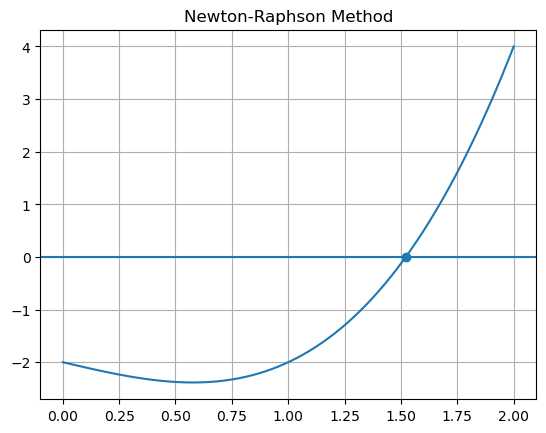

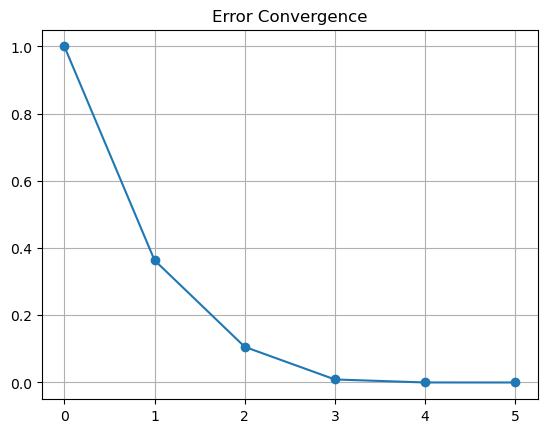

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Newton-Raphson Method
def newton_raphson(func, dfunc, x0, tol=1e-6, max_iter=100):

    errors = []
    iterations = []

    for _ in range(max_iter):

        x1 = x0 - func(x0)/dfunc(x0)

        error = abs(x1-x0)

        errors.append(error)
        iterations.append([x0,x1,func(x1),error])

        if error < tol:
            break

        x0 = x1

    return x1,errors,iterations


# function
f = lambda x: x**3 - x - 2
df = lambda x: 3*x**2 - 1

root,errors,iterations = newton_raphson(f,df,1)

print("Root ≈",root)

table = pd.DataFrame(iterations,
columns=["x_old","x_new","f(x_new)","Error"])
print(table)

# plot
x = np.linspace(0,2,500)
y = f(x)

plt.plot(x,y)
plt.axhline(0)
plt.scatter(root,f(root))
plt.title("Newton-Raphson Method")
plt.grid()
plt.show()

plt.plot(errors,marker='o')
plt.title("Error Convergence")
plt.grid()
plt.show()

Root ≈ 1.521379636045493
           a  b         c          f(c)         Error
0   1.000000  2  1.333333 -9.629630e-01  9.629630e-01
1   1.333333  2  1.462687 -3.333389e-01  3.333389e-01
2   1.462687  2  1.504019 -1.018180e-01  1.018180e-01
3   1.504019  2  1.516331 -2.989480e-02  2.989480e-02
4   1.516331  2  1.519919 -8.675066e-03  8.675066e-03
5   1.519919  2  1.520957 -2.508805e-03  2.508805e-03
6   1.520957  2  1.521258 -7.248228e-04  7.248228e-04
7   1.521258  2  1.521344 -2.093499e-04  2.093499e-04
8   1.521344  2  1.521370 -6.046133e-05  6.046133e-05
9   1.521370  2  1.521377 -1.746113e-05  1.746113e-05
10  1.521377  2  1.521379 -5.042711e-06  5.042711e-06
11  1.521379  2  1.521379 -1.456314e-06  1.456314e-06
12  1.521379  2  1.521380 -4.205770e-07  4.205770e-07


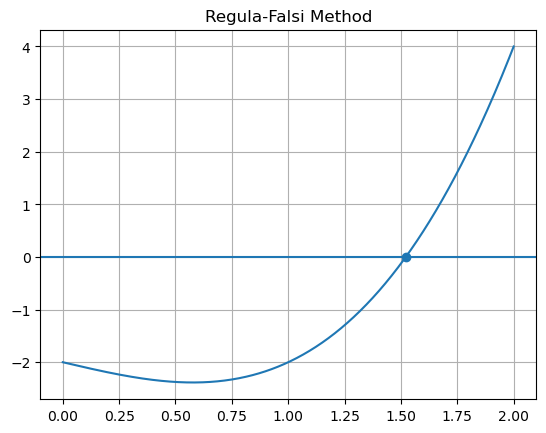

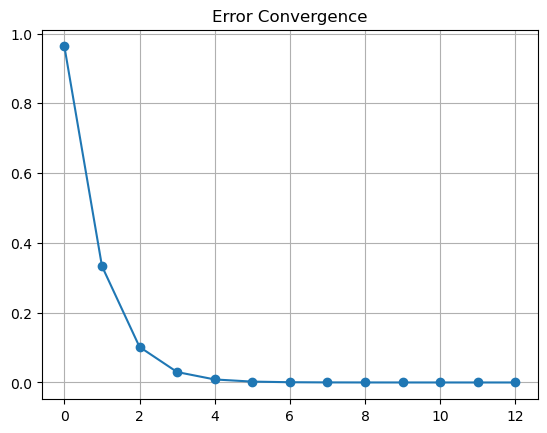

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------
# Regula-Falsi Method
# -------------------------------
def regula_falsi(func, a, b, tol=1e-6, max_iter=100):

    if func(a) * func(b) >= 0:
        raise ValueError("f(a) and f(b) must have opposite signs.")

    errors = []
    iterations = []

    for _ in range(max_iter):

        c = (a*func(b) - b*func(a)) / (func(b) - func(a))
        fc = func(c)

        error = abs(fc)

        errors.append(error)
        iterations.append([a, b, c, fc, error])

        if abs(fc) < tol:
            break

        if func(a)*fc < 0:
            b = c
        else:
            a = c

    return c, errors, iterations


# Example function
f = lambda x: x**3 - x - 2

root, errors, iterations = regula_falsi(f,1,2)

print("Root ≈",root)

table = pd.DataFrame(iterations,columns=["a","b","c","f(c)","Error"])
print(table)

# Plot function
x = np.linspace(0,2,500)
y = f(x)

plt.plot(x,y)
plt.axhline(0)
plt.scatter(root,f(root))
plt.title("Regula-Falsi Method")
plt.grid()
plt.show()

# Error convergence
plt.plot(errors,marker='o')
plt.title("Error Convergence")
plt.grid()
plt.show()

Root ≈ 1.5213797068045645
         x0        x1        x2         f(x2)         Error
0  1.000000  2.000000  1.333333 -9.629630e-01  6.666667e-01
1  2.000000  1.333333  1.462687 -3.333389e-01  1.293532e-01
2  1.333333  1.462687  1.531169  5.862642e-02  6.848286e-02
3  1.462687  1.531169  1.520926 -2.693300e-03  1.024301e-02
4  1.531169  1.520926  1.521376 -2.015019e-05  4.498962e-04
5  1.520926  1.521376  1.521380  7.015478e-09  3.391315e-06
6  1.521376  1.521380  1.521380 -1.842970e-14  1.180307e-09


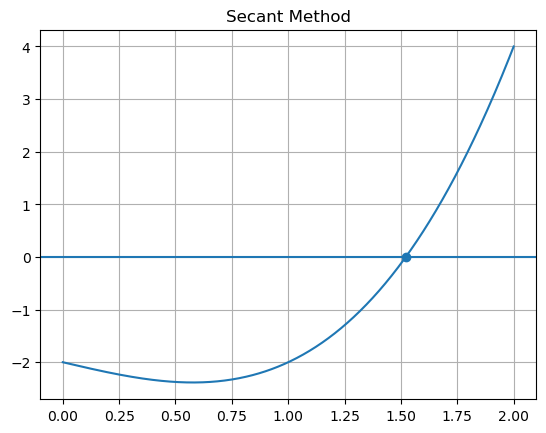

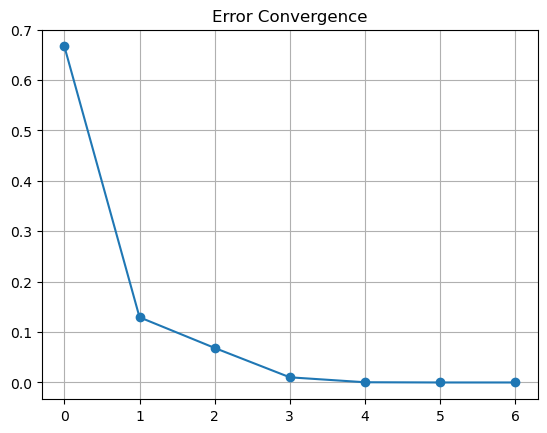

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Secant Method
def secant_method(func,x0,x1,tol=1e-6,max_iter=100):

    errors=[]
    iterations=[]

    for _ in range(max_iter):

        x2 = x1 - func(x1)*(x1-x0)/(func(x1)-func(x0))

        error = abs(x2-x1)

        errors.append(error)
        iterations.append([x0,x1,x2,func(x2),error])

        if error < tol:
            break

        x0 = x1
        x1 = x2

    return x2,errors,iterations


# function
f = lambda x: x**3 - x - 2

root,errors,iterations = secant_method(f,1,2)

print("Root ≈",root)

table = pd.DataFrame(iterations,
columns=["x0","x1","x2","f(x2)","Error"])
print(table)

# plot
x = np.linspace(0,2,500)
y = f(x)

plt.plot(x,y)
plt.axhline(0)
plt.scatter(root,f(root))
plt.title("Secant Method")
plt.grid()
plt.show()

plt.plot(errors,marker='o')
plt.title("Error Convergence")
plt.grid()
plt.show()